# Loss landscapes & gradient variations

How the reconstruction loss and its gradient vary as you move each track parameter — the
diagnostic that tells you a fit is well-posed (smooth basin, gradient crossing zero at truth).
Replaces the old per-loss / per-dimension scan notebooks with the library seams: the **data** via
`lucid.gradient_analysis` (`sweep_1d`/`sweep_2d`, `RECO_SWEEPS`) over the canonical
`lucid.fitting.ReconModel.loss`; the **plots** are in-cell (plots are notebook content).

In [1]:
%matplotlib inline
import sys; sys.path.append('../..')
import jax, jax.numpy as jnp, numpy as np
import matplotlib.pyplot as plt
from lucid.simulation import setup_event_simulator
from lucid.detector_params import ParticleParams
from lucid.fitting import ReconModel
from lucid.gradient_analysis import sweep_1d, sweep_2d, RECO_SWEEPS

GEOM, PHYS = '../../config/SK_like_geom_config.json', '../../config/SK_like_physics_config.json'
K = 8; GRID = dict(n_cap=80, n_angular=120, n_height=80)
det_sim = setup_event_simulator(GEOM, 250_000, temperature=None, K=K, hit_mode='realistic',
                                physics_config=PHYS, default_detector_params=True, particle='muon',
                                wavelength_mode=True, charge_resolution=None, **GRID)
pred = setup_event_simulator(GEOM, 250_000, temperature=0.1, K=K, hit_mode='per_photon', physics_config=PHYS,
                             default_detector_params=True, particle='muon', wavelength_mode=True,
                             pos_grad_threshold=K, n_grad_iters=K, **GRID)

### A truth track + self-consistent data (forward at truth → the loss minimum sits at truth)

In [2]:
truth = ParticleParams.from_cartesian(energy=1000., position=[2., -1., 3.], direction=[1., 0.3, 0.2], t0=0.)
oc, ot = jax.lax.stop_gradient(det_sim(truth, jax.random.PRNGKey(0)))
oc = jnp.asarray(oc); ot = jnp.where(oc > 0, jnp.asarray(ot), 0.)
model = ReconModel(pred, int(oc.shape[0]), sigma=2.5, delta=1.0)
print(f'{int((oc>0).sum())} PMTs lit, total charge {float(oc.sum()):.0f}')

key = jax.random.PRNGKey(1)
def pp_to_vec9(pp):
    return jnp.array([pp.energy, pp.position[0], pp.position[1], pp.position[2],
                      jnp.sin(pp.theta), jnp.cos(pp.theta), jnp.sin(pp.phi), jnp.cos(pp.phi), pp.t0])
loss_and_grad = jax.jit(jax.value_and_grad(lambda pp: model._loss(pp_to_vec9(pp), oc, ot, key)))

10301 PMTs lit, total charge 4662


### 1D scans — loss (top) + gradient (bottom) vs X, Y, Z, t0, Energy

Each loss should be a smooth basin with its minimum at truth (pink); each gradient should cross
zero there. This is the per-parameter well-posedness check.

X:   0%|          | 0/41 [00:00<?, ?it/s]

X:   2%|▏         | 1/41 [00:33<22:36, 33.91s/it]

X:   7%|▋         | 3/41 [00:34<05:36,  8.85s/it]

X:  12%|█▏        | 5/41 [00:34<02:35,  4.33s/it]

X:  17%|█▋        | 7/41 [00:34<01:25,  2.53s/it]

...

Energy:  83%|████████▎ | 34/41 [00:02<00:00, 15.03it/s]

Energy:  88%|████████▊ | 36/41 [00:02<00:00, 15.03it/s]

Energy:  93%|█████████▎| 38/41 [00:02<00:00, 15.02it/s]

Energy:  98%|█████████▊| 40/41 [00:02<00:00, 15.00it/s]

Energy: 100%|██████████| 41/41 [00:02<00:00, 15.04it/s]

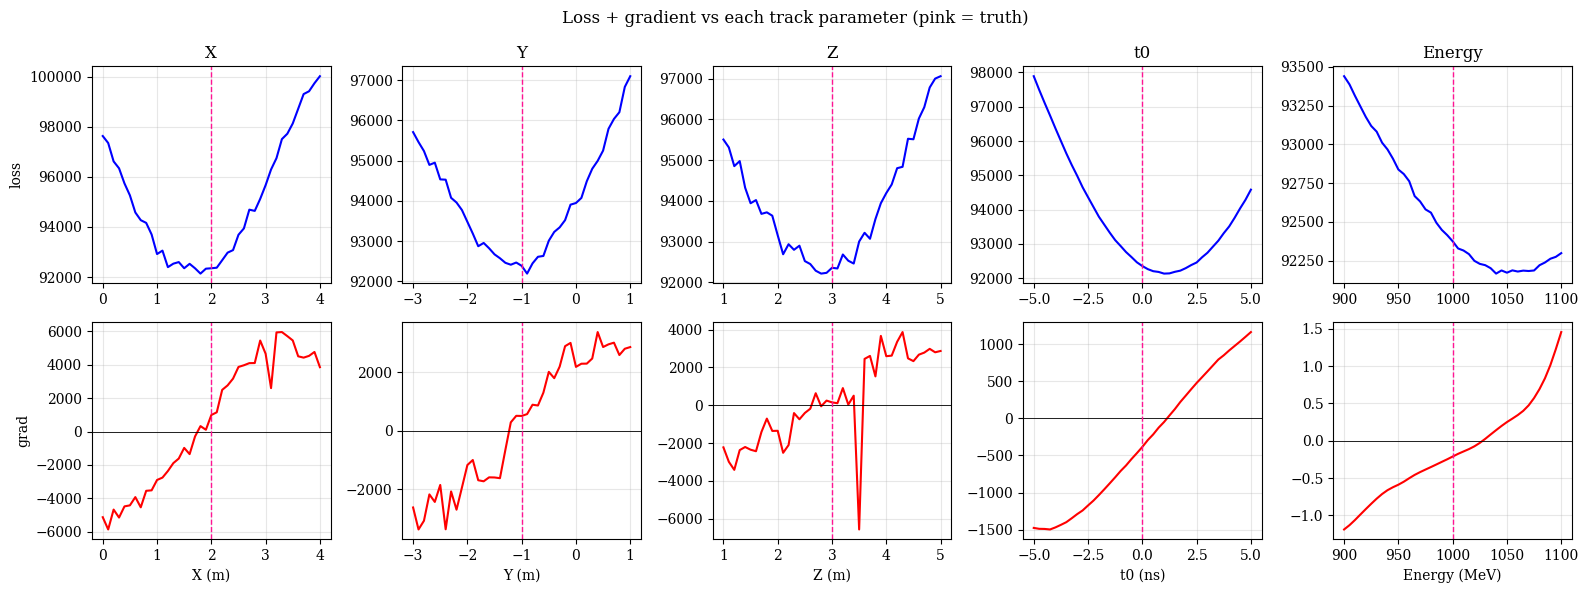

In [3]:
res1d = sweep_1d(loss_and_grad, truth, RECO_SWEEPS[:5])
names = list(res1d); n = len(names)
fig, ax = plt.subplots(2, n, figsize=(3.2 * n, 6), squeeze=False)
for j, nm in enumerate(names):
    r = res1d[nm]
    ax[0, j].plot(r.values, r.losses, 'b-'); ax[0, j].axvline(r.param.center, color='deeppink', ls='--', lw=1)
    ax[0, j].set_title(nm); ax[0, j].grid(alpha=.3); ax[0, j].set_ylabel('loss' if j == 0 else '')
    ax[1, j].plot(r.values, r.gradients, 'r-'); ax[1, j].axhline(0, color='k', lw=.6)
    ax[1, j].axvline(r.param.center, color='deeppink', ls='--', lw=1)
    ax[1, j].set_xlabel(r.param.label); ax[1, j].grid(alpha=.3); ax[1, j].set_ylabel('grad' if j == 0 else '')
fig.suptitle('Loss + gradient vs each track parameter (pink = truth)'); fig.tight_layout(); plt.show()

### 2D landscape — vertex X–Z plane (the longitudinal direction is the hard one)

X x Z:   0%|          | 0/31 [00:00<?, ?it/s]

X x Z:   3%|▎         | 1/31 [00:02<01:04,  2.16s/it]

X x Z:   6%|▋         | 2/31 [00:04<01:02,  2.15s/it]

X x Z:  10%|▉         | 3/31 [00:06<01:00,  2.15s/it]

X x Z:  13%|█▎        | 4/31 [00:08<00:57,  2.14s/it]

...

X x Z:  90%|█████████ | 28/31 [00:59<00:06,  2.11s/it]

X x Z:  94%|█████████▎| 29/31 [01:01<00:04,  2.11s/it]

X x Z:  97%|█████████▋| 30/31 [01:03<00:02,  2.11s/it]

X x Z: 100%|██████████| 31/31 [01:05<00:00,  2.11s/it]

X x Z: 100%|██████████| 31/31 [01:05<00:00,  2.12s/it]

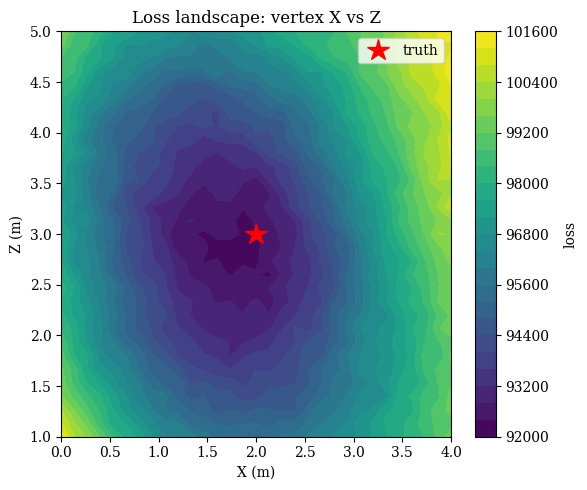

In [4]:
from dataclasses import replace
X = replace(RECO_SWEEPS[0], num_points=31); Z = replace(RECO_SWEEPS[2], num_points=31)
r2 = sweep_2d(loss_and_grad, truth, X, Z)
fig, axx = plt.subplots(figsize=(6, 5))
cf = axx.contourf(r2.x_values, r2.y_values, r2.losses.T, levels=30, cmap='viridis')
axx.plot(truth.position[0], truth.position[2], 'r*', ms=16, label='truth')
axx.set_xlabel(X.label); axx.set_ylabel(Z.label); axx.set_title('Loss landscape: vertex X vs Z'); axx.legend()
fig.colorbar(cf, ax=axx, label='loss'); fig.tight_layout(); plt.show()

Swap the `RECO_SWEEPS[...]` axes for any pair (Energy×t0, θ×φ) or change `truth`. To turn a
landscape into a fit, hand the same `ReconModel` to `fit_track_multistart` —
see `../reconstruction/reconstruct_a_track.ipynb`.